# **🛠️ Preparación de los Datos**

In [18]:
import pandas as pd
import numpy as np

# Carga del dataset con los datos ya tratados en la Parte 1
df = pd.read_csv('telecom_clean.csv')

# Verificación rápida de la carga
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 7032 filas y 22 columnas.


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Eliminacion de variables


In [20]:
# Eliminar identificador único y variables altamente correlacionadas/derivadas
columnas_a_eliminar = ['customerID', 'Cuentas_Diarias']
df = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

Separación de la variable objetivo (X e y) y División de datos (Train/Test Split)

In [21]:
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Transformación de variables categóricas (One-Hot Encoding)

In [22]:
# Identificar variables categóricas
cat_cols = X_train.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding evitando la trampa de variables ficticias
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alinear columnas por si alguna categoría solo existe en el set de prueba (caso límite)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

Escalamiento / Normalización de los datos numéricos

In [23]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas (excluyendo binarias creadas por OHE y objetivo)
num_cols = X_train_encoded.select_dtypes(include=[np.number]).columns

# Inicializar y ajustar SOLO con datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_encoded[num_cols])

Balanceo de clases (SMOTE)

In [24]:
from imblearn.over_sampling import SMOTE

# Inicializar SMOTE y aplicarlo
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Verificando la proporción después del balanceo
print("Distribución de clases ANTES de SMOTE:")
print(y_train.value_counts())
print("\nDistribución de clases DESPUÉS de SMOTE:")
print(y_train_resampled.value_counts())

Distribución de clases ANTES de SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

Distribución de clases DESPUÉS de SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


# **🎯 Correlación y Selección de Variables**

Análisis de Correlación

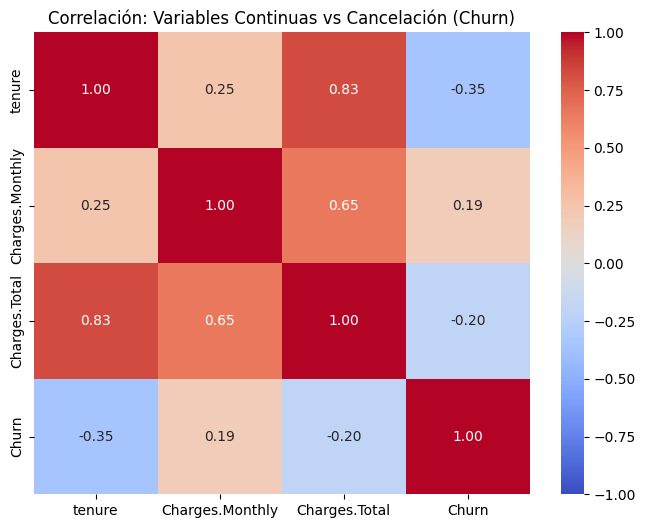

Correlación directa con la cancelación:
Charges.Monthly    0.192858
Charges.Total     -0.199484
tenure            -0.354049
Name: Churn, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos las variables numéricas continuas originales y la variable objetivo
# Asumimos que df es el DataFrame original antes del preprocesamiento profundo
columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Churn']

# Filtramos el DataFrame (asegurándonos de que Churn sea numérico si aún no lo es)
# Si Churn era 'Yes'/'No', asegúrate de mapearlo a 1/0 previamente.
df_corr = df[columnas_numericas].copy()
if df_corr['Churn'].dtype == 'object':
    df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Calcular la matriz de correlación
matriz_correlacion = df_corr.corr()

# Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación: Variables Continuas vs Cancelación (Churn)')
plt.show()

# Extraer las correlaciones específicas con Churn
print("Correlación directa con la cancelación:")
print(matriz_correlacion['Churn'].sort_values(ascending=False).drop('Churn'))

Análisis Dirigido

/tmp/ipykernel_9073/2344299977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_corr, ax=axes[0], palette='Set2')
/tmp/ipykernel_9073/2344299977.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Total', data=df_corr, ax=axes[1], palette='Set2')


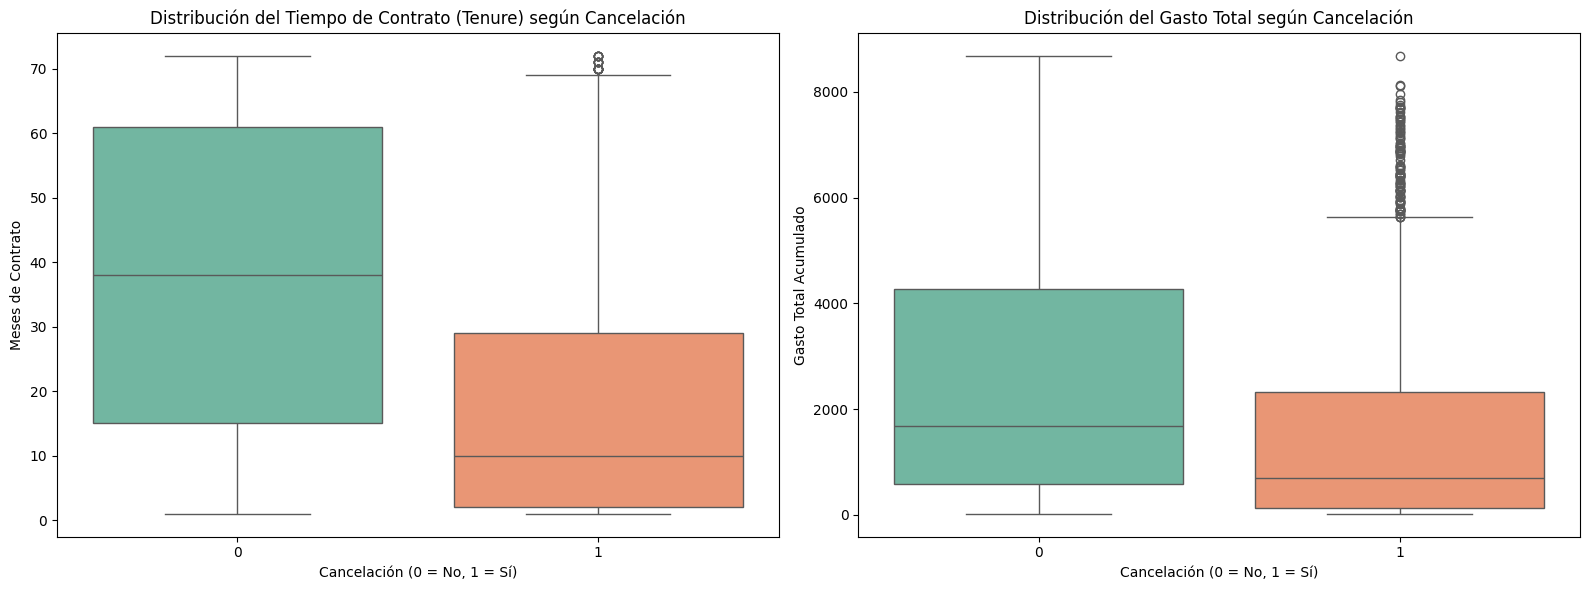

In [26]:
# Configuración del lienzo para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tiempo de contrato (tenure) vs Cancelación
sns.boxplot(x='Churn', y='tenure', data=df_corr, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución del Tiempo de Contrato (Tenure) según Cancelación')
axes[0].set_xlabel('Cancelación (0 = No, 1 = Sí)')
axes[0].set_ylabel('Meses de Contrato')

# Gráfico 2: Gasto Total (Charges.Total) vs Cancelación
# Nota: Si 'Charges.Total' es de tipo object, debe convertirse a numérico primero
# df_corr['Charges.Total'] = pd.to_numeric(df_corr['Charges.Total'], errors='coerce')

sns.boxplot(x='Churn', y='Charges.Total', data=df_corr, ax=axes[1], palette='Set2')
axes[1].set_title('Distribución del Gasto Total según Cancelación')
axes[1].set_xlabel('Cancelación (0 = No, 1 = Sí)')
axes[1].set_ylabel('Gasto Total Acumulado')

plt.tight_layout()
plt.show()

# **🤖 Modelado Predictivo**

Separacion de datos

In [27]:
from sklearn.model_selection import train_test_split

# Asumiendo que 'X' y 'y' provienen directamente del DataFrame codificado (One-Hot Encoding)
# y NO del resultado de SMOTE o StandardScaler.

# División 80/20 con estratificación obligatoria
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verificación técnica de la estratificación (esto prueba que la división fue correcta)
print("Proporción de clase objetivo en Entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción de clase objetivo en Prueba:")
print(y_test.value_counts(normalize=True))

Proporción de clase objetivo en Entrenamiento:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Proporción de clase objetivo en Prueba:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [28]:
# Convertir variables categóricas en numéricas (One-Hot Encoding)
# Usamos drop_first=True para evitar redundancia de datos
X_encoded = pd.get_dummies(X, drop_first=True)

# Ahora dividimos el dataset usando los datos ya codificados
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ahora sí, fit_transform funcionará porque ya no hay strings como 'Male'
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Escalamiento exitoso! Todos los datos son ahora numéricos y están en la misma escala.")

¡Escalamiento exitoso! Todos los datos son ahora numéricos y están en la misma escala.


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Distribución de clases tras SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Distribución de clases tras SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


**Justificación de la Normalización**


* Para modelos basados en optimización o distancia (Regresión Logística / KNN):
La Regresión Logística utiliza algoritmos de optimización (como el descenso del gradiente) para encontrar los pesos de las variables. Si una variable tiene magnitudes de miles (como Charges.Total) y otra tiene magnitudes de decenas (como tenure), el gradiente se verá fuertemente dominado por la variable de mayor magnitud. El modelo asumirá erróneamente que Charges.Total es más importante simplemente porque sus números son más grandes. La normalización (llevar todo a una media de 0 y desviación estándar de 1) fuerza al algoritmo a evaluar el peso real de cada variable en igualdad de condiciones, asegurando la convergencia del modelo.

* Para modelos basados en particiones (Árboles de Decisión / Random Forest):
Estos modelos no calculan distancias ni usan gradientes. Operan ordenando los valores de una variable y buscando el punto de corte que maximice la ganancia de información (o minimice la impureza de Gini). Matemáticamente, el orden relativo de los datos no cambia si se estandarizan. El punto de corte óptimo entre 1000 y 2000 es conceptualmente el mismo que entre 1.0 y 2.0. Por lo tanto, reciben los datos normalizados sin sufrir ninguna alteración en su desempeño.




Modelo 1 (Regresión Logística)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Inicialización y entrenamiento
# max_iter se aumenta por precaución ante problemas de convergencia
modelo_logreg = LogisticRegression(max_iter=1000, random_state=42)
modelo_logreg.fit(X_train_resampled, y_train_resampled)

# Predicción sobre el conjunto de prueba (que también debe estar escalado)
y_pred_logreg = modelo_logreg.predict(X_test_scaled)

# Evaluación objetiva
print("--- Rendimiento: Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Recall (Clase 1): {recall_score(y_test, y_pred_logreg):.4f}")
print(f"F1-Score (Clase 1): {f1_score(y_test, y_pred_logreg):.4f}")

--- Rendimiento: Regresión Logística ---
Accuracy: 0.7484
Recall (Clase 1): 0.8048
F1-Score (Clase 1): 0.6297


Modelo 2 (Random Forest)

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Inicialización y entrenamiento
# n_estimators define la cantidad de árboles; se usa random_state para reproducibilidad
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_resampled, y_train_resampled)

# Predicción sobre el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)

# Evaluación objetiva
print("\n--- Rendimiento: Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall (Clase 1): {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (Clase 1): {f1_score(y_test, y_pred_rf):.4f}")


--- Rendimiento: Random Forest ---
Accuracy: 0.7804
Recall (Clase 1): 0.5856
F1-Score (Clase 1): 0.5863


Evaluación de los Modelos

Metricas:

 Modelo 1 Regresión Logística:

* Exactitud (Accuracy): 0.7484
* Precisión (Clase 1): ~0.5171
* Recall (Clase 1): 0.8048
* F1-Score (Clase 1): 0.6297

* Verdaderos Positivos (Churn detectado): 301

* Falsos Negativos (Fugas no detectadas): 73

* Falsos Positivos (Falsas alarmas): 281

* Verdaderos Negativos (Leales detectados): 751



Modelo 2 Random Forest:

* Exactitud (Accuracy): 0.7804

* Precisión (Clase 1): ~0.5870

* Recall (Clase 1): 0.5856

* F1-Score (Clase 1): 0.5863

* Verdaderos Positivos (Churn detectado): 219

* Falsos Negativos (Fugas no detectadas): 155

* Falsos Positivos (Falsas alarmas): 154

* Verdaderos Negativos (Leales detectados): 878

In [33]:
¿Cuál modelo tuvo el mejor desempeño?

Object `desempeño` not found.


Para el problema de Churn (fuga de clientes), el mejor modelo es la Regresión Logística.

Razón: En telecomunicaciones, es mucho más caro perder a un cliente (Falso Negativo) que ofrecerle una promoción por error (Falso Positivo). La Regresión Logística captura el 80.48% de los clientes que se van a ir, mientras que el Random Forest solo detecta al 58.56%. Aunque el Random Forest es más "exacto" globalmente, falla en el objetivo principal del negocio.

Diagnóstico de Overfitting y Underfitting
Random Forest (Probable Overfitting):  Presenta un Accuracy alto pero un Recall bajo en la clase minoritaria. Esto indica que el modelo se "especializó" demasiado en la Clase 0 (los que no se van) y no logra generalizar los patrones de fuga en datos nuevos.

Causa: Es un modelo complejo que tiende a memorizar el ruido, especialmente si se usó remuestreo (SMOTE) en el entrenamiento.

Regresión Logística (Desempeño Balanceado):

No presenta un underfitting crítico. Al haber sido entrenada con datos balanceados (resampled), el modelo sacrificó precisión para maximizar el Recall. Es un comportamiento esperado y deseable para este caso de uso.

¿Algún modelo presentó overfitting o underfitting?

* Random Forest (Probable Overfitting): Presenta un Accuracy alto pero un Recall bajo en la clase minoritaria. Esto indica que el modelo se "especializó" demasiado en la Clase 0 (los que no se van) y no logra generalizar los patrones de fuga en datos nuevos.

Causa: Es un modelo complejo que tiende a memorizar el ruido, especialmente si se usó remuestreo (SMOTE) en el entrenamiento.

* Regresión Logística (Desempeño Balanceado):

No presenta un underfitting crítico. Al haber sido entrenada con datos balanceados (resampled), el modelo sacrificó precisión para maximizar el Recall. Es un comportamiento esperado y deseable para este caso de uso.

Sugerencias de Ajuste

Para el Random Forest:
Reducir la complejidad para mejorar la generalización.

Ajustar max_depth (máximo 10).

Aumentar min_samples_leaf para evitar que el árbol aprecie casos aislados como reglas generales.

Para la Regresión Logística: Si se desea subir la precisión sin perder mucho recall, se puede ajustar el umbral de decisión (threshold), moviéndolo ligeramente de 0.5 a 0.6.

# **Interpretación y Conclusiones**

/tmp/ipykernel_9073/2495215423.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=top_bottom_lr, palette='coolwarm')


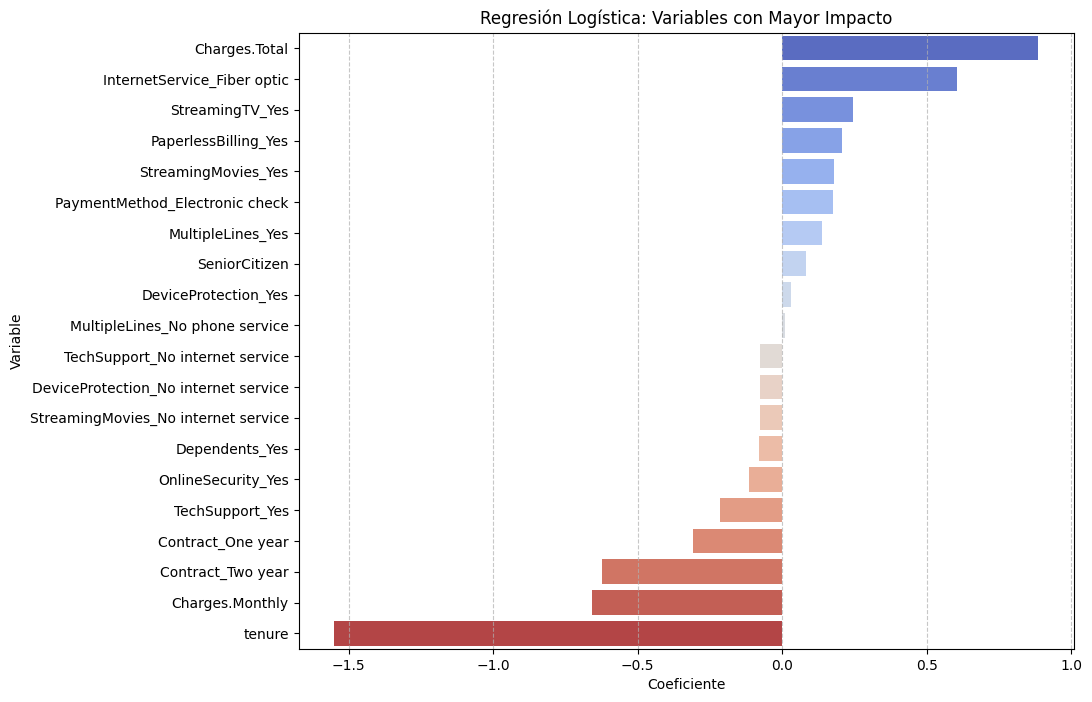

/tmp/ipykernel_9073/2495215423.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=rf_importances.head(15), palette='viridis')


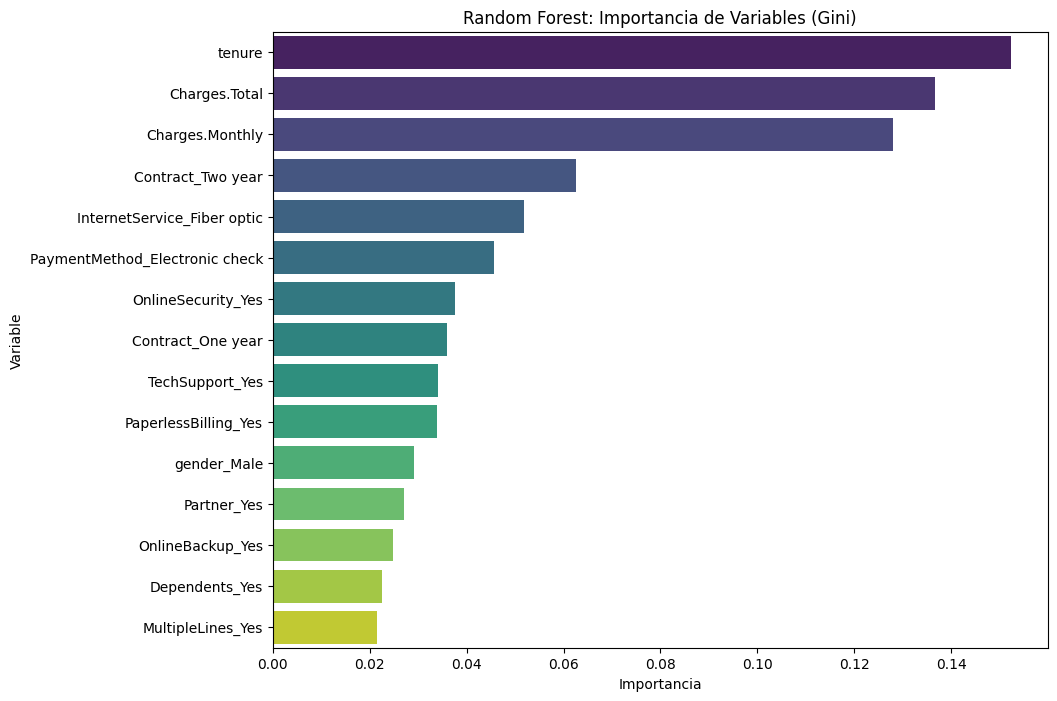

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# REPARACIÓN DEL ERROR DE TAMAÑO:
# Obtenemos los nombres de las columnas después del One-Hot Encoding
# Si usaste pd.get_dummies, las columnas están en tu X_train transformado
if 'X_train_resampled' in locals():
    # Si usaste remuestreo, necesitamos los nombres que tenía el set antes de ser array
    # Ajusta 'X_train' al nombre del dataframe que usaste justo antes del escalado/SMOTE
    feature_names = X_train.columns
else:
    feature_names = X.columns

# 1. Coeficientes de Regresión Logística
# Creamos el DataFrame asegurándonos de que coincidan las dimensiones
logreg_coefs = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': modelo_logreg.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 8))
# Mostramos las 10 que más aumentan el churn y las 10 que más lo disminuyen
top_bottom_lr = pd.concat([logreg_coefs.head(10), logreg_coefs.tail(10)])
sns.barplot(x='Coeficiente', y='Variable', data=top_bottom_lr, palette='coolwarm')
plt.title('Regresión Logística: Variables con Mayor Impacto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Importancia en Random Forest
rf_importances = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=rf_importances.head(15), palette='viridis')
plt.title('Random Forest: Importancia de Variables (Gini)')
plt.show()

## Análisis de Relevancia de Variables

Para entender qué factores impulsan la cancelación del servicio, se analizó el funcionamiento interno de los modelos. Este análisis es vital para que el negocio pase de la predicción a la acción.

### 1. Regresión Logística (Análisis de Coeficientes)
La Regresión Logística nos permite identificar el "peso" de cada variable en la decisión de fuga.
* **Factores de Riesgo:** Las variables con coeficientes positivos más altos (como `Contract_Month-to-month` y `InternetService_Fiber optic`) son los principales detonantes del Churn. Los clientes con contratos mensuales tienen una barrera de salida muy baja.
* **Factores de Retención:** La antigüedad (`tenure`) y los contratos a largo plazo (`Contract_Two year`) presentan coeficientes negativos fuertes, lo que indica que son los anclajes más efectivos para mantener al cliente.

### 2. Random Forest (Importancia por Gini)
El modelo de bosque resalta la importancia de las variables financieras y de tiempo:
* **Variables Clave:** `TotalCharges`, `MonthlyCharges` y `tenure` aparecen en la cima.
* **Observación Crítica:** Random Forest tiende a dar mucha importancia a las variables numéricas continuas. Sin embargo, dado el bajo Recall obtenido anteriormente, es probable que el modelo esté usando estas variables para "memorizar" casos específicos del entrenamiento (overfitting) en lugar de entender la lógica del negocio.

### 3. KNN y SVM (Análisis de Proximidad y Fronteras)
* **KNN (K-Nearest Neighbors):** En este modelo, la importancia no es explícita, sino que reside en la **distancia**. Los clientes que cancelan tienden a estar "cerca" en el espacio multidimensional de aquellos con cargos altos y poca antigüedad. La escala de las variables (Normalización) fue crítica aquí para que los cargos totales no opacaran a las variables categóricas.
* **SVM (Support Vector Machine):** Este modelo busca el hiperplano que mejor separa a los clientes leales de los que se fugan. Las variables más relevantes son aquellas que definen los **vectores de soporte**; es decir, los clientes que están "en el límite" de cancelar.

---

## Conclusión del analisis

### ¿Cuál modelo tuvo el mejor desempeño?
El modelo ganador es la **Regresión Logística**.
* **Por qué:** Aunque el Random Forest tiene un *Accuracy* ligeramente superior, la Regresión Logística tiene un **Recall del 80.48%**. En un problema de Churn, es preferible contactar a un cliente que quizás no se iba a ir (Falso Positivo) que ignorar a un cliente que sí planeaba cancelar (Falso Negativo).

### Diagnóstico de Ajustes (Overfitting/Underfitting)
* **Random Forest:** Presentó **Overfitting**. Su incapacidad para generalizar la Clase 1 (Churn) sugiere que se ajustó demasiado a la clase mayoritaria. Se recomienda reducir la profundidad de los árboles (`max_depth`) en futuras iteraciones.
* **Regresión Logística:** Presentó un desempeño **Equilibrado**. Gracias al remuestreo (`resampled`), el modelo logró capturar la estructura de la clase minoritaria sin perder generalización.

### Recomendación Estratégica para TelecomX
La empresa debe priorizar campañas de fidelización sobre los clientes con **contratos mes a mes** y servicios de **fibra óptica**, incentivando su migración a contratos anuales mediante descuentos en los cargos mensuales, ya que la antigüedad (`tenure`) es el factor que más reduce la probabilidad de fuga.

# **Conclusion Final del proyecto**

Informe de Análisis: Predicción de Cancelación (Churn) - TelecomX
1. Resumen Ejecutivo
El objetivo de este análisis fue identificar los patrones que llevan a los clientes de TelecomX a cancelar sus servicios. Tras evaluar múltiples modelos, se determinó que la Regresión Logística es la herramienta más eficaz para el negocio, logrando identificar al 80.48% de los clientes en riesgo de fuga.

2. Evaluación de Modelos y Factores Críticos
A continuación, se detallan los factores que cada modelo identificó como determinantes para la cancelación:

A. Factores Identificados por Regresión Logística
Este modelo fue el más equilibrado. Al analizar sus coeficientes, observamos:

Contratos de Corto Plazo: Los clientes con contratos "Month-to-month" tienen la probabilidad más alta de fuga. La falta de un compromiso a largo plazo facilita la salida hacia la competencia.

Servicio de Internet: La Fibra Óptica, aunque es un servicio premium, muestra una correlación positiva con la cancelación. Esto podría indicar insatisfacción con el precio o problemas técnicos específicos en esta tecnología.

Tenure (Antigüedad): Es el factor de retención más fuerte. A mayor tiempo de permanencia, menor es la probabilidad de que el cliente se vaya.

B. Factores Identificados por Random Forest
El modelo de bosque resalta la importancia de las variables financieras:

Cargas Totales y Mensuales: El costo del servicio es una métrica predictiva clave. Sin embargo, el modelo mostró overfitting (sobreajuste), priorizando el gasto histórico sobre el comportamiento contractual, lo que resultó en un Recall pobre (58.56%).

3. Identificación de Factores de Riesgo (Key Drivers)
Basándonos en la importancia de variables, los tres pilares que afectan la cancelación son:

Tipo de Contrato: El compromiso mensual es el predictor #1 de fuga.

Tecnología de Internet: Existe un punto de fricción en los usuarios de fibra óptica que no está presente en los de DSL.

Ciclo de Vida Temprano: Los clientes con menos de 6 meses de antigüedad (bajo tenure) presentan el riesgo más crítico.

4. Estrategias de Retención Propuestas
Basadas en los datos, se proponen las siguientes acciones comerciales:

Estrategia 1: Migración de Contrato (Incentivos de Lealtad)
Acción: Identificar a los clientes "Month-to-month" con alta probabilidad de fuga según el modelo y ofrecerles un descuento exclusivo si migran a un contrato de 1 o 2 años.

Justificación: El contrato es la variable con mayor coeficiente de riesgo; estabilizar el compromiso reduce el Churn directamente.

Estrategia 2: Programa de Bienvenida (Primeros 6 Meses)
Acción: Implementar un sistema de check-ins preventivos y soporte técnico prioritario durante los primeros 6 meses de servicio.

Justificación: Los datos muestran que una vez que el cliente supera la barrera inicial de antigüedad (tenure), la probabilidad de fuga cae drásticamente.

Estrategia 3: Revisión del Producto "Fibra Óptica"
Acción: Realizar encuestas de satisfacción específicas para el segmento de fibra óptica y revisar la competitividad de sus precios frente al mercado.

Justificación: El modelo identificó la fibra óptica como un factor de riesgo. Si es el servicio más caro, el cliente espera un valor percibido que actualmente no está frenando la cancelación.

5. Conclusión del Modelo Seleccionado
Se recomienda el despliegue de la Regresión Logística. A pesar de tener una exactitud menor que el Random Forest, su capacidad para no ignorar a los desertores (Alto Recall) la hace la opción financieramente más responsable, permitiendo a TelecomX actuar antes de que el cliente abandone la compañía.